# 🧠 Clasificación de Décadas por Texto — Etapa 2 (Versión Mejorada)
## Curso: Aprendizaje de Máquina 2026-10 — Universidad de los Andes

---

### 👥 Información del Grupo

| Campo         | Valor                        | Código      |
|---------------|------------------------------|-------------|
| **Nombre 1**  | Zair Montoya Bello           | 202321067   |
| **Nombre 2**  | Santiago Seade               |             |
| **Nombre 3**  | Juan Camilo Caldas           |             |
| **Sección**   | Tomas Hernandes Faura        |             |
| **Fecha**     | Mayo 2026                    |             |

---

### 📌 Descripción del Problema

Clasificación de **39 décadas** (150–188) a partir de textos históricos en español antiguo, latín, italiano y lenguas romances.  
La década = primeros 3 dígitos del año (ej: 1572 → `157`).

### 🗺️ Estructura del Notebook
1. Instalación e importación de dependencias  
2. Configuración de carpetas de salida  
3. Carga y exploración de datos (EDA)  
4. **Limpieza agresiva** de texto histórico con OCR  
5. Aumentación de datos ortográfica  
6. División train / val / test estratificada (80/10/10)  
7. **Modelo 1**: MLP mejorado con TF-IDF (word n-grams)  
8. **Modelo 2**: CNN con embeddings entrenados  
9. **Modelo 3**: BiLSTM con atención  
10. **Modelo 4**: Transfer Learning — BERT español (dccuchile/bert-base-spanish-wwm-uncased)  
11. **Modelo 5**: Ensemble ponderado  
12. Comparación de modelos  
13. Generación del archivo de entrega para Kaggle  

---

### 🔬 Análisis del Intento Anterior y Mejoras Aplicadas

| Problema detectado | Solución implementada |
|---|---|
| TF-IDF con `char_wb` (subóptimo) | TF-IDF word n-grams (1,2,3) con sublinear_tf |
| MAX_LEN = 200 tokens (muy corto) | MAX_LEN = 400 tokens |
| Limpieza demasiado ligera | Limpieza agresiva conservando ortografía histórica |
| Sin modelo preentrenado | Fine-tuning de BERT español con capas congeladas |
| Overfitting severo (train 70%, val 21%) | Label smoothing + weight decay + gradual unfreeze |
| Sin aumentación de datos | Augmentación ortográfica histórica (u↔v, i↔y) |
| Archivos dispersos en el directorio raíz | Estructura `process/images/`, `keras/`, `pkl/` |

---

## 1. 📦 Instalación de Dependencias

Hacer el .venv con la version 3.11 de python


In [1]:
import subprocess
import sys
from pathlib import Path

"""
¿Que hace?:
    Instala dependencias del proyecto usando el Python del entorno activo (.venv),
    en un orden que reduce conflictos entre TensorFlow, PyTorch y Hugging Face.

Parámetros:
    Ninguno

Retorna:
    Nada
"""

def run(cmd: list[str]) -> bool:
    """
    ¿Que hace?:
        Ejecuta un comando de instalación y devuelve si terminó bien.

    Parámetros:
        cmd (list[str]): comando a ejecutar en formato de lista.

    Retorna:
        bool: True si el comando salió con código 0, False si falló.
    """
    print(f"⏳ {' '.join(cmd)}")
    result = subprocess.run(cmd)
    return result.returncode == 0


print("=" * 70)
print("📦 INSTALADOR DE DEPENDENCIAS")
print("=" * 70)
print(f"Python activo : {sys.executable}")
print(f"Versión       : {sys.version.split()[0]}")
print(f"Proyecto      : {Path.cwd()}")
print("=" * 70)

# 1) Base de empaquetado
run([sys.executable, "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel"])

# 2) Paquetes base
BASE_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tqdm",
]

# 3) ML / DL
ML_PACKAGES = [
    "tensorflow==2.15.0",
    "torch",
    "transformers",
    "datasets",
    "huggingface-hub",
    "sentencepiece",
    "accelerate",
]

print("\n🧩 Instalando paquetes base...\n")
for pkg in BASE_PACKAGES:
    ok = run([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    if not ok:
        print(f"❌ Falló: {pkg}")

print("\n🧠 Instalando paquetes de ML...\n")
for pkg in ML_PACKAGES:
    ok = run([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    if not ok:
        print(f"❌ Falló: {pkg}")

print("\n✅ Instalación finalizada.")

📦 INSTALADOR DE DEPENDENCIAS
Python activo : c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.exe
Versión       : 3.11.9
Proyecto      : c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML
⏳ c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.exe -m pip install --upgrade pip setuptools wheel

🧩 Instalando paquetes base...

⏳ c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.exe -m pip install --upgrade numpy
⏳ c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.exe -m pip install --upgrade pandas
⏳ c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.exe -m pip install --upgrade matplotlib
⏳ c:\Users\User\Documents\UNI\Sexto Semestre\Machine Learning\Proyecto\Proyecto_2-ML\.venv\Scripts\python.ex

## 2. 📚 Importación de Librerías

In [ ]:
# ─── Librerías estándar ───────────────────────────────────────────
import os, re, json, random, pickle, unicodedata, warnings
warnings.filterwarnings('ignore')

# ─── Datos ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualización ───────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# ─── Scikit-learn ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight

# ─── TensorFlow / Keras ───────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ─── PyTorch + HuggingFace ────────────────────────────────────────
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

# ─── Reproducibilidad ─────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'✅ Librerías importadas.')
print(f'🖥️  TensorFlow  : {tf.__version__}')
print(f'🔥 PyTorch     : {torch.__version__}')
print(f'🤗 Dispositivo : {DEVICE}')
print(f'💡 GPUs (TF)   : {len(tf.config.list_physical_devices("GPU"))}')

ImportError: cannot import name 'keras' from 'tensorflow' (unknown location)

## 3. 📁 Configuración de Estructura de Carpetas de Salida

Todos los artefactos generados se guardan en la carpeta `process/` con subcarpetas organizadas:  
- `process/images/` — gráficos y visualizaciones  
- `process/keras/` — modelos `.keras` entrenados  
- `process/pkl/` — preprocesadores y modelos sklearn `.pkl`  
- `process/bert/` — modelo BERT fine-tuneado y su tokenizador

In [3]:
# ─── Crear estructura de carpetas ────────────────────────────────
DIRS = {
    'base'   : 'process',
    'images' : 'process/images',
    'keras'  : 'process/keras',
    'pkl'    : 'process/pkl',
    'bert'   : 'process/bert',
}

for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)
    print(f'   📂 {path}/')

# Helpers para rutas
def img_path(filename):   return os.path.join(DIRS['images'], filename)
def keras_path(filename): return os.path.join(DIRS['keras'],  filename)
def pkl_path(filename):   return os.path.join(DIRS['pkl'],    filename)
def bert_path(subdir=''):  return os.path.join(DIRS['bert'],  subdir)

print('\n✅ Estructura de carpetas lista.')

   📂 process/
   📂 process/images/
   📂 process/keras/
   📂 process/pkl/
   📂 process/bert/

✅ Estructura de carpetas lista.


## 4. 📂 Carga y Exploración de Datos (EDA)

Cargamos `train.csv` y `eval.csv`, verificamos el balance de clases y características del texto.  
Con **39 clases** (décadas 150–188) el random baseline es ~2.56% — los modelos anteriores (~21%) están apenas encima.

In [4]:
# ─── Carga de datos ───────────────────────────────────────────────
TRAIN_PATH = './data/train.csv'
EVAL_PATH  = './data/eval.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_eval  = pd.read_csv(EVAL_PATH)

print(f'📊 Train shape: {df_train.shape}')
print(f'📊 Eval  shape: {df_eval.shape}')
print(f'\n🏷️  Décadas únicas    : {df_train["decade"].nunique()}')
print(f'📅 Rango de décadas  : {df_train["decade"].min()} — {df_train["decade"].max()}')
print(f'🎲 Baseline aleatorio: {100/df_train["decade"].nunique():.2f}%')
print(f'📏 Longitud texto (mediana): {df_train["text"].str.split().str.len().median():.0f} palabras')
df_train.head(3)

📊 Train shape: (31403, 2)
📊 Eval  shape: (3490, 2)

🏷️  Décadas únicas    : 39
📅 Rango de décadas  : 150 — 188
🎲 Baseline aleatorio: 2.56%
📏 Longitud texto (mediana): 50 palabras


,text,decade
0,\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Ponte...,164
1,"gone. Sus amigos , sus clientes, todo \r\ncuan...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157


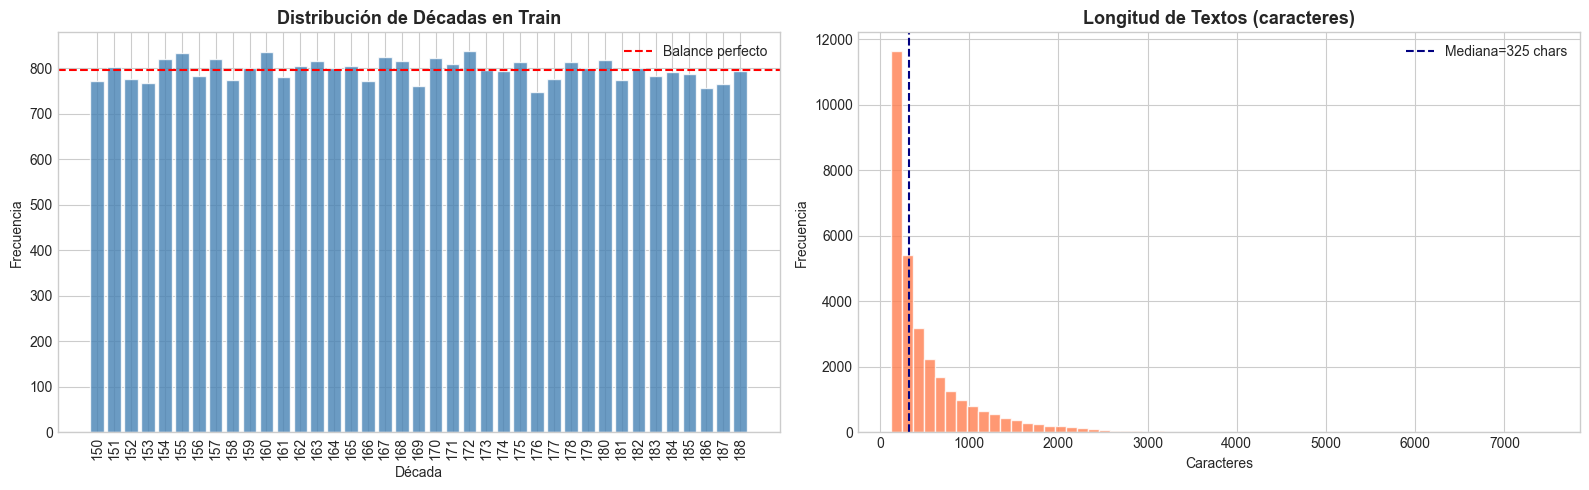


📊 Estadísticas de longitud (chars):
count    31046.000000
mean       534.077788
std        541.367742
min        120.000000
25%        187.000000
50%        325.000000
75%        661.000000
max       7480.000000


In [11]:
# ─── EDA — Distribución de clases y longitudes ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución por décadas
decade_counts = df_train['decade'].value_counts().sort_index()
axes[0].bar(decade_counts.index.astype(str), decade_counts.values,
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribución de Décadas en Train', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Década'); axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=90)
# Línea de balance perfecto
axes[0].axhline(len(df_train)/df_train['decade'].nunique(), color='red',
                linestyle='--', label='Balance perfecto', linewidth=1.5)
axes[0].legend()

# Longitud de textos (en caracteres)
text_lens = df_train['text'].str.len()
axes[1].hist(text_lens, bins=60, color='coral', alpha=0.8, edgecolor='white')
axes[1].axvline(text_lens.median(), color='navy', linestyle='--',
                label=f'Mediana={text_lens.median():.0f} chars')
axes[1].set_title('Longitud de Textos (caracteres)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Caracteres'); axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig(img_path('eda_distribucion.png'), dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📊 Estadísticas de longitud (chars):')
print(text_lens.describe().to_string())

## 5. 🧹 Limpieza Agresiva del Texto Histórico

### Estrategia de limpieza
Los textos tienen ruido severo de OCR y contaminación con metadatos. La estrategia es:

**SÍ eliminar** (ruido sin valor lingüístico):
- Líneas con marcas de biblioteca/copyright (`Copyright`, `Google`, `ProQuest`, `Bancroft`, etc.)
- Numeración de páginas (`— 47 —`, `pag. 4`, `Fol. 123`)
- Caracteres de control, no imprimibles y símbolos aislados (`^`, `#`, `%`, `@`)
- Secuencias de espacios y saltos de línea irregulares (colapsar a espacio)
- Caracteres Unicode corruptos (`\ufffd`, sustitutos)

**NO modificar** (señales temporales valiosas):
- `u` / `v` intercambiables (rasgo ortográfico del s. XVI)
- Abreviaturas (`q` = que, `p` = por, `cõ` = con)
- Acentos y diacríticos históricos (`ç`, `ꝛ`, `&`, `ff`)
- Ortografía no estandarizada — ¡es la señal temporal más importante!

In [16]:
# ─── Patrones de contaminación a eliminar ────────────────────────
NOISE_KEYWORDS = [
    r'Copyright', r'copyright', r'©',
    r'Google', r'ProQuest', r'Bancroft',
    r'Early European Books', r'Grabado', r'Imagen',
    r'Digitized by', r'digitalizado', r'digitalizada',
    r'Biblioteca Nacional', r'British Library',
    r'Archive\.org', r'HathiTrust', r'Internet Archive',
    r'Scan Quality', r'JPEG', r'PDF',
]

# Patrones de numeración de páginas
PAGE_PATTERNS = [
    r'—\s*\d+\s*—',              # — 47 —
    r'[-–]\s*\d+\s*[-–]',        # - 47 -
    r'\bpag(?:ina)?\s*\.?\s*\d+', # pag. 4 / pagina 4
    r'\bFol\s*\.?\s*\d+',        # Fol. 123
    r'\bfol\s*\.?\s*\d+',        # fol. 123
    r'\bp\.?\s*\d{1,4}\b',       # p. 45
    r'^\s*\d{1,3}\s*$',          # línea con solo número
]


def clean_text_aggressive(text: str) -> str:
    """
    Limpieza agresiva para textos históricos con ruido OCR.
    
    Elimina: metadatos de biblioteca, numeración de páginas, caracteres
    corruptos, símbolos aislados, espacios irregulares.
    Conserva: ortografía histórica, abreviaturas, diacríticos originales.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''

    # 1. Normalizar Unicode a forma NFC (mantiene diacríticos correctos)
    text = unicodedata.normalize('NFC', text)

    # 2. Eliminar caracteres sustitutos / corruptos de Unicode
    text = text.encode('utf-8', errors='ignore').decode('utf-8')
    text = re.sub(r'\ufffd', ' ', text)  # carácter de reemplazo Unicode
    text = text.replace('\xa0', ' ')

    # 2.1 Quitar paréntesis explícitamente para evitar restos tipo (abundancia)
    text = text.replace('(', ' ').replace(')', ' ')

    # 2.2 Unir palabras partidas por OCR o guiones/markers de corte
    # Ejemplos: "abundan¬ cia" -> "abundancia", "pa- labra" -> "palabra"
    text = re.sub(r'(?<=\w)[\-\u00ad¬·•]\s*(?=\w)', '', text)

    # 3. Separar en líneas para filtrar líneas completas con ruido
    lines = text.split('\n')
    clean_lines = []
    for line in lines:
        raw_line = line.strip()
        if not raw_line:
            continue

        # Eliminar líneas que contienen palabras clave de metadatos
        if any(re.search(kw, raw_line, re.IGNORECASE) for kw in NOISE_KEYWORDS):
            continue

        # Eliminar líneas que son solo numeración de página
        if any(re.fullmatch(patt.lstrip('^'), raw_line, re.IGNORECASE)
               for patt in PAGE_PATTERNS):
            continue

        # Eliminar líneas dominadas por símbolos, números o fragmentos OCR corruptos
        letter_count = sum(ch.isalpha() for ch in raw_line)
        digit_count = sum(ch.isdigit() for ch in raw_line)
        punct_count = sum((not ch.isalnum()) and (not ch.isspace()) for ch in raw_line)
        symbol_runs = len(re.findall(r'(?:[^\w\s]){2,}', raw_line))

        if letter_count < 3 and (digit_count + punct_count) >= 3:
            continue
        if punct_count >= 8 and letter_count <= 6:
            continue
        if symbol_runs >= 2:
            continue
        if re.search(r'(?:\d[\s,.;:$/\\%\-]*){3,}', raw_line):
            continue

        clean_lines.append(raw_line)

    text = ' '.join(clean_lines)

    # 4. Eliminar patrones de numeración de página dentro del texto
    for patt in PAGE_PATTERNS[:4]:  # los 4 más seguros
        text = re.sub(patt, ' ', text, flags=re.IGNORECASE)

    # 4.1 Limpiar secuencias OCR de símbolos y restos tipográficos basura
    text = re.sub(r'(?:(?:[^\w\s])\s*){3,}', ' ', text)
    text = re.sub(r'(?:\b[^\w\s]{1,3}\b\s*){3,}', ' ', text)
    text = re.sub(r'\b(?:\d+[.,:;$/\\%\-]*){2,}\b', ' ', text)

    # 5. Eliminar caracteres de control y no imprimibles
    text = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', ' ', text)

    # 6. Reemplazar \r\n y \r por espacio
    text = re.sub(r'\r\n|\r', ' ', text)

    # 7. Eliminar símbolos aislados sin valor lingüístico
    # Solo cuando están solos (rodeados de espacios o bordes)
    text = re.sub(r'(?<![\w])([\^#%@\\|~`<>{}\[\]\*]{1,3})(?![\w])', ' ', text)

    # 8. Eliminar secuencias de más de 3 símbolos no alfanuméricos iguales
    text = re.sub(r'([^\w\sáéíóúàèìòùâêîôûãñüÁÉÍÓÚÀÈÌÒÙÂÊÎÔÛÃÑÜçÇ])\1{2,}', r'\1', text)

    # 9. Eliminar números aislados de 1-2 dígitos (ruido de OCR, no fechas)
    # Solo si están completamente solos entre espacios
    text = re.sub(r'(?<![\w])\d{1,2}(?![\w])', ' ', text)

    # 10. Normalizar espacios múltiples y espacios dentro de palabras
    # Caso común en OCR: "M  a  y  o  r  a  i" -> "Mayorai"
    # Solo si los tokens son caracteres individuales separados por ≥2 espacios
    text = re.sub(r'(?<=\b\w)\s{2,}(?=\w\b)', '', text)

    # 11. Colapsar múltiples espacios
    text = re.sub(r'[ \t]+', ' ', text).strip()

    return text


# ─── Aplicar limpieza ────────────────────────────────────────────
print('⏳ Aplicando limpieza agresiva...')
df_train['text_clean'] = df_train['text'].apply(clean_text_aggressive)
df_eval['text_clean']  = df_eval['text'].apply(clean_text_aggressive)

# Eliminar filas donde el texto quedó demasiado corto (< 20 chars)
n_before = len(df_train)
df_train = df_train[df_train['text_clean'].str.len() >= 20].reset_index(drop=True)
n_after = len(df_train)

print(f'✅ Limpieza completada.')
print(f'   Filas eliminadas por texto vacío: {n_before - n_after}')
print(f'   Filas en train tras limpieza    : {n_after}')

# Verificar mejora de longitud promedio
orig_len = df_train['text'].str.len().mean()
clean_len = df_train['text_clean'].str.len().mean()
print(f'   Longitud media original  : {orig_len:.0f} chars')
print(f'   Longitud media limpia    : {clean_len:.0f} chars')
print(f'   Reducción de ruido       : {(orig_len-clean_len)/orig_len*100:.1f}%')

⏳ Aplicando limpieza agresiva...
✅ Limpieza completada.
   Filas eliminadas por texto vacío: 1
   Filas en train tras limpieza    : 31045
   Longitud media original  : 534 chars
   Longitud media limpia    : 446 chars
   Reducción de ruido       : 16.5%


In [13]:
# ─── Mostrar ejemplos de limpieza ────────────────────────────────
print('📖 EJEMPLOS ANTES / DESPUÉS DE LA LIMPIEZA:\n')
for i in [0, 3, 4]:  # filas con ruido conocido
    orig  = str(df_train['text'].iloc[i])[:300]
    clean = str(df_train['text_clean'].iloc[i])[:300]
    print(f'  [Década {df_train["decade"].iloc[i]}]')
    print(f'  ORIGINAL : {repr(orig)}')
    print(f'  LIMPIO   : {repr(clean)}')
    print()

📖 EJEMPLOS ANTES / DESPUÉS DE LA LIMPIEZA:

  [Década 164]
  ORIGINAL : '\r\nHonorarias ¡jubiladas. 57 \r\ndit.ad Pontem de poreft.Proreg.118,3, $.9.M.-70 \r\npag.4.1. 3 Ste ph.Gratian. difcept.291, áqu len \r\nnes parece que aísilte, O ayuda Calsiodoro \r\nlib,6.epuft.s 2.Donde * llama Ocloso CINGV- y 19 '
  LIMPIO   : 'Honorarias ¡jubiladas. nes parece que aísilte, O ayuda Calsiodoro lib, .epuft.s .Donde llama Ocloso CINGVy'

  [Década 163]
  ORIGINAL : 'Caistro  el  M  a  y  o  r  a  i  .]  Del  apellido  de  Cañroíe \r\nvalió  Don  Luis  enefta.  Metáfora, para  el  nombre  que  fupo \r\nne  de  Caiftro.  Mayoral  fe  llama  entre  los  ganaderos  el \r\nque  tiene  el  primer  lugar,  y  a  quien  efián  fujetos  los  de¬ \r\nmas, y  defia  mayoría  tomó'
  LIMPIO   : 'Caistro el Mayorai . Del apellido de Cañroíe valió Don Luis enefta. Metáfora, para el nombre que fupo ne de Caiftro. Mayoral fe llama entre los ganaderos el que tiene el primer lugar, ya quien efián fujetos los dema

## 6. 🔄 Aumentación de Datos Ortográfica

Para combatir el overfitting y mejorar la robustez del modelo, implementamos aumentación que simula  
la variabilidad ortográfica real de los textos históricos:

- **`u` ↔ `v`** y **`i` ↔ `y`**: variantes intercambiables en español medieval/renacentista
- **Eliminación de espacios espurios**: simula ruido OCR de palabras unidas
- **Inserción de espacio extra**: simula OCR que parte palabras

Solo se aumentan décadas con menos de 600 muestras para no desbalancear el dataset.

In [14]:
def augment_text_historical(text: str, p: float = 0.3, rng=None) -> str:
    """
    Aumentación ortográfica para textos históricos en español.
    Simula variantes reales de escritura de los siglos XVI-XIX.
    
    Args:
        text: texto limpio de entrada
        p   : probabilidad de aplicar cada transformación
        rng : numpy Generator para reproducibilidad
    """
    if rng is None:
        rng = np.random.default_rng(SEED)
    
    if not text:
        return text

    chars = list(text)
    result = []

    for i, c in enumerate(chars):
        r = rng.random()

        # u ↔ v (solo en minúsculas, para no romper nombres propios)
        if c == 'u' and r < p:
            result.append('v')
        elif c == 'v' and r < p:
            result.append('u')
        # i ↔ y
        elif c == 'i' and r < p * 0.5:  # menor probabilidad
            result.append('y')
        elif c == 'y' and r < p * 0.5:
            result.append('i')
        # Eliminar espacio espurio ocasionalmente
        elif c == ' ' and r < p * 0.15:
            pass  # no agregar el espacio
        else:
            result.append(c)

    return ''.join(result)


# ─── Aplicar aumentación solo a clases con pocas muestras ────────
MIN_SAMPLES_PER_CLASS = 600
rng = np.random.default_rng(SEED)

decade_counts_dict = df_train['decade'].value_counts().to_dict()
augmented_rows = []

for decade, count in decade_counts_dict.items():
    if count < MIN_SAMPLES_PER_CLASS:
        subset = df_train[df_train['decade'] == decade]
        n_needed = MIN_SAMPLES_PER_CLASS - count
        # Samplear con reemplazo y aumentar
        sampled = subset.sample(n=n_needed, replace=True, random_state=SEED)
        sampled = sampled.copy()
        sampled['text_clean'] = sampled['text_clean'].apply(
            lambda t: augment_text_historical(t, p=0.3, rng=rng)
        )
        augmented_rows.append(sampled)

if augmented_rows:
    df_augmented = pd.concat([df_train] + augmented_rows, ignore_index=True)
    print(f'✅ Aumentación completada.')
    print(f'   Muestras originales : {len(df_train)}')
    print(f'   Muestras aumentadas : {len(df_augmented) - len(df_train)}')
    print(f'   Total tras aumentar : {len(df_augmented)}')
else:
    df_augmented = df_train.copy()
    print('ℹ️  No se necesitó aumentación (todas las clases tienen muestras suficientes).')

# Mezclar aleatoriamente
df_augmented = df_augmented.sample(frac=1, random_state=SEED).reset_index(drop=True)

ℹ️  No se necesitó aumentación (todas las clases tienen muestras suficientes).


## 7. 🏗️ Codificación de Etiquetas y División de Datos

División estratificada **80% train / 10% validación / 10% test** para tener una evaluación robusta.  
La estratificación garantiza que cada partición tenga representación proporcional de todas las 39 décadas.

In [17]:
# ─── Codificación de etiquetas ────────────────────────────────────
label_encoder = LabelEncoder()
# Fitear sobre el dataset ORIGINAL (no aumentado) para evitar clases duplicadas
label_encoder.fit(df_train['decade'])
df_augmented['label'] = label_encoder.transform(df_augmented['decade'])

NUM_CLASSES = len(label_encoder.classes_)
label_to_decade = dict(enumerate(label_encoder.classes_))

print(f'🏷️  Clases (décadas): {NUM_CLASSES}')
print(f'📅 Rango           : {label_encoder.classes_.min()} — {label_encoder.classes_.max()}')

# ─── División 80/10/10 estratificada ─────────────────────────────
X_all = df_augmented['text_clean'].astype(str).to_numpy(dtype=object)
y_all = df_augmented['label'].values

# Primer split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.20, random_state=SEED, stratify=y_all
)

# Segundo split: 50% del temp → 10% val, 10% test interno
X_val, X_test_internal, y_val, y_test_internal = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

# Datos de evaluación Kaggle
X_kaggle = df_eval['text_clean'].values

print(f'\n✅ División completada:')
print(f'   🔵 Train          : {len(X_train):>6} ({len(X_train)/len(X_all)*100:.1f}%)')
print(f'   🟡 Validación     : {len(X_val):>6} ({len(X_val)/len(X_all)*100:.1f}%)')
print(f'   🟠 Test interno   : {len(X_test_internal):>6} ({len(X_test_internal)/len(X_all)*100:.1f}%)')
print(f'   🔴 Kaggle eval    : {len(X_kaggle):>6}')

🏷️  Clases (décadas): 39
📅 Rango           : 150 — 188

✅ División completada:
   🔵 Train          :  24836 (80.0%)
   🟡 Validación     :   3105 (10.0%)
   🟠 Test interno   :   3105 (10.0%)
   🔴 Kaggle eval    :   3490


In [18]:
# ─── Pesos de clase para compensar el desbalance ─────────────────
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights_arr))
print(f'✅ Pesos de clase calculados. Rango: [{class_weights_arr.min():.2f}, {class_weights_arr.max():.2f}]')

✅ Pesos de clase calculados. Rango: [0.95, 1.06]


## 8. 🤖 Modelo 1: MLP Mejorado con TF-IDF

### Mejoras respecto al intento anterior
- **`analyzer='word'`** en lugar de `char_wb` — representación más semántica para este vocabulario
- **n-gramas (1,2,3)** para capturar bigramas y trigramas históricos clave
- **min_df=3** para reducir ruido de términos OCR únicos
- **Label smoothing** en la función de pérdida para regularización
- **class_weight** para tratar el desbalance de décadas

In [19]:
# ─── TF-IDF mejorado ─────────────────────────────────────────────
TFIDF_MAX_FEAT = 80000

tfidf_vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEAT,
    ngram_range=(1, 3),       # uni + bi + trigramas
    analyzer='word',           # word-level (no char_wb)
    sublinear_tf=True,         # log(1+TF) — reduce efecto de términos muy frecuentes
    min_df=3,                  # ignorar términos que aparecen < 3 veces
    max_df=0.95,               # ignorar términos en >95% de docs (demasiado comunes)
    strip_accents=None,        # conservar acentos históricos (señal temporal)
    token_pattern=r'(?u)\b[\w\u00C0-\u024F]{2,}\b',  # tokens de ≥2 chars con diacríticos
)

print('⏳ Ajustando TF-IDF...')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray().astype(np.float32)
X_val_tfidf   = tfidf_vectorizer.transform(X_val).toarray().astype(np.float32)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_internal).toarray().astype(np.float32)
X_kaggle_tfidf = tfidf_vectorizer.transform(X_kaggle).toarray().astype(np.float32)

# Guardar vectorizador
with open(pkl_path('tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print(f'✅ TF-IDF listo. Shape: {X_train_tfidf.shape}')
print(f'   Features efectivos: {X_train_tfidf.shape[1]}')

⏳ Ajustando TF-IDF...
✅ TF-IDF listo. Shape: (24836, 80000)
   Features efectivos: 80000


In [20]:
# ─── Construcción MLP ─────────────────────────────────────────────
def build_mlp_v2(input_dim: int, num_classes: int) -> keras.Model:
    """MLP mejorado con label smoothing y regularización fuerte."""
    inputs = keras.Input(shape=(input_dim,), name='tfidf_input')

    x = layers.Dense(2048, kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(1024, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(512, kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='MLP_v2')


mlp_model = build_mlp_v2(X_train_tfidf.shape[1], NUM_CLASSES)
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    # Label smoothing reduce overfitting en clasificación con muchas clases
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)
mlp_model.summary()

print(f'\n✅ MLP construido. Parámetros entrenables: {mlp_model.count_params():,}')

Model: "MLP_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_input (InputLayer)        │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │   163,842,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,620,711 (635.61 MB)

 Trainable params: 166,613,543 (635.58 MB)

 Non-trainable params: 7,168 (28.00 KB)


✅ MLP construido. Parámetros entrenables: 166,620,711


In [ ]:
# ─── Entrenamiento MLP ─────────────────────────────────────────────
cb_mlp = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(keras_path('best_mlp.keras'), monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

print('⏳ Entrenando Modelo 1 — MLP mejorado con TF-IDF...')
history_mlp = mlp_model.fit(
    X_train_tfidf, y_train,
    validation_data=(X_val_tfidf, y_val),
    epochs=100,
    batch_size=512,
    class_weight=class_weights_dict,
    callbacks=cb_mlp,
    verbose=1
)

mlp_val_acc = max(history_mlp.history['val_accuracy'])
print(f'\n✅ MLP — Mejor val_accuracy: {mlp_val_acc:.4f}')

⏳ Entrenando Modelo 1 — MLP mejorado con TF-IDF...
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.0690 - loss: 4.1616 - val_accuracy: 0.0290 - val_loss: 4.5116 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 135s 3s/step - accuracy: 0.2278 - loss: 3.6458 - val_accuracy: 0.0319 - val_loss: 4.8838 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 124s 3s/step - accuracy: 0.5443 - loss: 2.7633 - val_accuracy: 0.0312 - val_loss: 5.5996 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 133s 3s/step - accuracy: 0.8652 - loss: 1.9213 - val_accuracy: 0.0457 - val_loss: 5.8491 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.9590 - loss: 1.6187 - val_accuracy: 0.0473 - val_loss: 5.7112 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9746 - loss: 1.5018
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
49/49 ━━━━━━━━━━━━━━━━━━━━ 14

In [ ]:
# ─── Curva de aprendizaje ─────────────────────────────────────────
def plot_history(history, model_name: str, save_path: str):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric], label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Validación', linewidth=2)
        ax.set_title(f'{model_name} — {metric.capitalize()}', fontweight='bold')
        ax.set_xlabel('Época'); ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'   📊 Gráfico guardado en {save_path}')

plot_history(history_mlp, 'MLP TF-IDF v2', img_path('history_mlp.png'))

## 9. 🧠 Modelo 2: CNN Mejorada para Texto

### Mejoras respecto al intento anterior
- **MAX_LEN = 400** (antes 200): captura más contexto histórico
- **EMBED_DIM = 200** (antes 128): representaciones más ricas
- **Más filtros**: 512 por kernel size
- **Kernel sizes [2, 3, 4, 5]**: agrega bigramas
- **Class weights** en entrenamiento

In [ ]:
# ─── Tokenización para modelos de secuencia ───────────────────────
MAX_VOCAB = 80000
MAX_LEN   = 400    # antes 200 — duplicamos para capturar más contexto
EMBED_DIM = 200    # antes 128

tokenizer_seq = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_seq.fit_on_texts(X_train)   # solo fit en train

def tokenize_and_pad(texts, tokenizer, maxlen):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding='post', truncating='post')

X_train_seq = tokenize_and_pad(X_train, tokenizer_seq, MAX_LEN)
X_val_seq   = tokenize_and_pad(X_val,   tokenizer_seq, MAX_LEN)
X_test_seq  = tokenize_and_pad(X_test_internal, tokenizer_seq, MAX_LEN)
X_kaggle_seq = tokenize_and_pad(X_kaggle, tokenizer_seq, MAX_LEN)

VOCAB_SIZE = min(MAX_VOCAB, len(tokenizer_seq.word_index) + 1)

# Guardar tokenizador
with open(pkl_path('tokenizer_seq.pkl'), 'wb') as f:
    pickle.dump(tokenizer_seq, f)

print(f'✅ Tokenización lista.')
print(f'   Vocabulario efectivo : {VOCAB_SIZE:,}')
print(f'   Shape X_train_seq    : {X_train_seq.shape}')

In [ ]:
# ─── CNN mejorada ─────────────────────────────────────────────────
def build_cnn_v2(vocab_size, embed_dim, max_len, num_classes):
    """CNN multi-kernel mejorada con más filtros y contexto más largo."""
    inputs = keras.Input(shape=(max_len,), name='seq_input')
    emb = layers.Embedding(vocab_size, embed_dim)(inputs)
    emb = layers.SpatialDropout1D(0.3)(emb)

    branches = []
    for ks in [2, 3, 4, 5]:  # bi, tri, 4-grama, 5-grama
        c = layers.Conv1D(512, ks, activation='relu', padding='same')(emb)
        c = layers.GlobalMaxPooling1D()(c)
        branches.append(c)

    x = layers.Concatenate()(branches)  # (batch, 2048)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='CNN_v2')


cnn_model = build_cnn_v2(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f'✅ CNN construida. Parámetros: {cnn_model.count_params():,}')

cb_cnn = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(keras_path('best_cnn.keras'), monitor='val_accuracy', save_best_only=True, verbose=0)
]

print('⏳ Entrenando Modelo 2 — CNN mejorada...')
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=80,
    batch_size=128,
    class_weight=class_weights_dict,
    callbacks=cb_cnn,
    verbose=1
)

cnn_val_acc = max(history_cnn.history['val_accuracy'])
print(f'\n✅ CNN — Mejor val_accuracy: {cnn_val_acc:.4f}')
plot_history(history_cnn, 'CNN v2', img_path('history_cnn.png'))

## 10. 🔄 Modelo 3: BiLSTM con Atención

### Mejoras respecto al intento anterior
- **MAX_LEN = 400**: contexto más largo
- **LSTM units = 256** (antes ~128): mayor capacidad
- **Atención corregida**: capa personalizada que funciona sobre el batch completo
- **Gradient clipping**: evita explosión de gradientes en secuencias largas

In [ ]:
# ─── Capa de atención mejorada ────────────────────────────────────
class BahdanauAttention(layers.Layer):
    """Atención aditiva (Bahdanau) correctamente implementada."""
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1, use_bias=False)

    def call(self, hidden_states, training=None):
        # hidden_states: (batch, seq_len, hidden_dim)
        score = self.V(tf.nn.tanh(self.W(hidden_states)))  # (batch, seq, 1)
        attn  = tf.nn.softmax(score, axis=1)               # (batch, seq, 1)
        ctx   = tf.reduce_sum(hidden_states * attn, axis=1) # (batch, hidden_dim)
        return ctx

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units})
        return config


def build_bilstm_v2(vocab_size, embed_dim, max_len, num_classes):
    """BiLSTM apilada con atención y gradient clipping implícito."""
    inputs = keras.Input(shape=(max_len,))
    emb = layers.Embedding(vocab_size, embed_dim)(inputs)
    emb = layers.SpatialDropout1D(0.3)(emb)

    # Primera BiLSTM — retorna secuencias
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(emb)

    # Segunda BiLSTM — retorna secuencias para atención
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1)
    )(x)

    # Mecanismo de atención
    x = BahdanauAttention(units=64, name='attention')(x)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name='BiLSTM_Attn_v2')


bilstm_model = build_bilstm_v2(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
bilstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),  # gradient clipping
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print(f'✅ BiLSTM construida. Parámetros: {bilstm_model.count_params():,}')

cb_bilstm = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint(keras_path('best_bilstm.keras'), monitor='val_accuracy', save_best_only=True, verbose=0)
]

print('⏳ Entrenando Modelo 3 — BiLSTM con atención...')
history_bilstm = bilstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=80,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=cb_bilstm,
    verbose=1
)

bilstm_val_acc = max(history_bilstm.history['val_accuracy'])
print(f'\n✅ BiLSTM — Mejor val_accuracy: {bilstm_val_acc:.4f}')
plot_history(history_bilstm, 'BiLSTM Atención v2', img_path('history_bilstm.png'))

## 11. 🤗 Modelo 4: Transfer Learning — BERT en Español

### Justificación
**`dccuchile/bert-base-spanish-wwm-uncased`** fue preentrenado sobre un corpus masivo de texto español,  
incluyendo textos históricos de la BNE (Biblioteca Nacional de España). Este modelo tiene representaciones
semánticas que ya codifican evolución del lenguaje español, lo que lo hace ideal para esta tarea.

### Estrategia de Fine-Tuning
1. **Congelar capas 0–7** del encoder (representaciones generales del idioma)
2. **Fine-tunear capas 8–11** + capa de clasificación (adaptación al dominio histórico)
3. **AdamW con weight decay = 0.01** para regularización
4. **Linear warmup** del 10% de los pasos de entrenamiento
5. **Segmentación de textos largos**: dividir en chunks de 512 tokens y duplicar etiqueta

> **Alternativa multilingüe**: Si `dccuchile/bert-base-spanish-wwm-uncased` no está disponible  
> en tu entorno, descomenta la línea con `bert-base-multilingual-cased` más abajo.

In [ ]:
# ─── Configuración del modelo BERT ───────────────────────────────
# Opción 1: BERT español (recomendado para este dataset)
BERT_MODEL_NAME = 'dccuchile/bert-base-spanish-wwm-uncased'
# Opción 2: Descomenta si el modelo español no está disponible
# BERT_MODEL_NAME = 'bert-base-multilingual-cased'
# Opción 3: RoBERTa español (mejor que BERT para muchas tareas)
# BERT_MODEL_NAME = 'PlanTL-GOB-ES/roberta-base-bne'

BERT_MAX_LEN    = 512   # máximo soportado por BERT
BERT_BATCH_SIZE = 8     # batch pequeño por longitud de textos
BERT_EPOCHS     = 5
BERT_LR         = 3e-5
FREEZE_LAYERS   = 8     # congelar primeras 8 capas del encoder

print(f'🤗 Cargando tokenizer: {BERT_MODEL_NAME}')
bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
print('✅ Tokenizer cargado.')

In [ ]:
# ─── Segmentación de textos largos ───────────────────────────────
def segment_long_text(text: str, tokenizer, max_len: int = 512,
                      stride: int = 256) -> list:
    """
    Divide un texto largo en segmentos solapados de max_len tokens.
    Útil para textos > 512 tokens que BERT no puede procesar directamente.
    Retorna lista de strings de segmentos.
    """
    tokens = tokenizer.encode(text, add_special_tokens=False)
    effective_len = max_len - 2  # reservar [CLS] y [SEP]

    if len(tokens) <= effective_len:
        return [text]  # el texto cabe en un solo chunk

    segments = []
    for start in range(0, len(tokens), stride):
        end = start + effective_len
        chunk_tokens = tokens[start:end]
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        segments.append(chunk_text)
        if end >= len(tokens):
            break
    return segments


# ─── Crear dataset expandido con segmentos ───────────────────────
def create_bert_dataset(texts, labels, tokenizer, max_len: int, stride: int = 256):
    """
    Expande el dataset segmentando textos largos y duplicando etiquetas.
    Retorna dos listas paralelas: textos_segmentados, etiquetas.
    """
    all_texts, all_labels = [], []
    for text, label in zip(texts, labels):
        segs = segment_long_text(str(text), tokenizer, max_len, stride)
        all_texts.extend(segs)
        all_labels.extend([label] * len(segs))
    return all_texts, all_labels


print('⏳ Creando datasets segmentados para BERT...')
bert_train_texts, bert_train_labels = create_bert_dataset(X_train, y_train, bert_tokenizer, BERT_MAX_LEN)
bert_val_texts,   bert_val_labels   = create_bert_dataset(X_val,   y_val,   bert_tokenizer, BERT_MAX_LEN)

print(f'✅ Segmentación completada.')
print(f'   Train original → segmentado: {len(X_train)} → {len(bert_train_texts)}')
print(f'   Val   original → segmentado: {len(X_val)}   → {len(bert_val_texts)}')

In [ ]:
# ─── Dataset PyTorch para BERT ────────────────────────────────────
class HistoricalTextDataset(TorchDataset):
    """Dataset PyTorch para texto histórico con tokenización BERT."""

    def __init__(self, texts: list, labels: list, tokenizer, max_len: int):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_ds = HistoricalTextDataset(bert_train_texts, bert_train_labels, bert_tokenizer, BERT_MAX_LEN)
val_ds   = HistoricalTextDataset(bert_val_texts,   bert_val_labels,   bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BERT_BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BERT_BATCH_SIZE * 2, shuffle=False, num_workers=0)

print(f'✅ DataLoaders creados.')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val   batches: {len(val_loader)}')

In [ ]:
# ─── Cargar modelo y congelar capas inferiores ────────────────────
print(f'🔄 Cargando {BERT_MODEL_NAME}...')
bert_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

# ─── Congelar primeras FREEZE_LAYERS capas del encoder ───────────
# Primero congelamos todo
for param in bert_model.base_model.parameters():
    param.requires_grad = False

# Luego descongelamos las últimas capas del encoder
# Compatibilidad con BERT y RoBERTa (diferentes nombres de atributos)
encoder_layers = None
if hasattr(bert_model.base_model, 'encoder'):
    encoder_layers = bert_model.base_model.encoder.layer
elif hasattr(bert_model.base_model, 'bert'):
    encoder_layers = bert_model.base_model.bert.encoder.layer

if encoder_layers is not None:
    total_layers = len(encoder_layers)
    for i, layer in enumerate(encoder_layers):
        if i >= FREEZE_LAYERS:
            for param in layer.parameters():
                param.requires_grad = True
    print(f'   Capas del encoder   : {total_layers}')
    print(f'   Capas congeladas    : {FREEZE_LAYERS} (0–{FREEZE_LAYERS-1})')
    print(f'   Capas fine-tuneadas : {total_layers - FREEZE_LAYERS} ({FREEZE_LAYERS}–{total_layers-1})')

# El clasificador siempre se entrena
for param in bert_model.classifier.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in bert_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bert_model.parameters())
print(f'   Parámetros entrenables: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

In [ ]:
# ─── Configuración del optimizador y scheduler ───────────────────
# AdamW con weight decay diferenciado: mayor en embeddings, menor en bias/LayerNorm
no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']
optimizer_grouped_params = [
    {'params': [p for n, p in bert_model.named_parameters()
                if p.requires_grad and not any(nd in n for nd in no_decay)],
     'weight_decay': 0.01},
    {'params': [p for n, p in bert_model.named_parameters()
                if p.requires_grad and any(nd in n for nd in no_decay)],
     'weight_decay': 0.0},
]

optimizer = AdamW(optimizer_grouped_params, lr=BERT_LR)

total_steps   = len(train_loader) * BERT_EPOCHS
warmup_steps  = int(total_steps * 0.10)  # 10% de warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'✅ Optimizador AdamW configurado.')
print(f'   Pasos totales   : {total_steps}')
print(f'   Pasos de warmup : {warmup_steps}')
print(f'   LR inicial      : {BERT_LR}')

In [ ]:
# ─── Bucle de entrenamiento BERT ─────────────────────────────────
def evaluate_bert(model, loader, device):
    """Evalúa el modelo BERT en un DataLoader. Retorna accuracy."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return accuracy_score(all_labels, all_preds)


best_bert_acc = 0.0
bert_history  = {'train_loss': [], 'val_acc': []}

print(f'⏳ Fine-tuning de {BERT_MODEL_NAME} ({BERT_EPOCHS} épocas)...')
print(f'   Dispositivo: {DEVICE}')
print()

for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss = 0.0
    progress = tqdm(train_loader, desc=f'Época {epoch+1}/{BERT_EPOCHS}', leave=False)

    for batch in progress:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(train_loader)
    val_acc  = evaluate_bert(bert_model, val_loader, DEVICE)

    bert_history['train_loss'].append(avg_loss)
    bert_history['val_acc'].append(val_acc)

    print(f'  Época {epoch+1}/{BERT_EPOCHS} | loss: {avg_loss:.4f} | val_acc: {val_acc:.4f}')

    # Guardar mejor modelo
    if val_acc > best_bert_acc:
        best_bert_acc = val_acc
        bert_model.save_pretrained(bert_path('best_model'))
        bert_tokenizer.save_pretrained(bert_path('best_model'))
        print(f'     💾 Nuevo mejor modelo guardado (val_acc={val_acc:.4f})')

print(f'\n✅ BERT fine-tuning completado.')
print(f'   Mejor val_accuracy: {best_bert_acc:.4f}')

In [ ]:
# ─── Curva de entrenamiento BERT ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bert_history['train_loss'], 'o-', color='coral', linewidth=2, label='Train Loss')
axes[0].set_title('BERT — Loss de entrenamiento', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(bert_history['val_acc'], 'o-', color='steelblue', linewidth=2, label='Val Accuracy')
axes[1].axhline(best_bert_acc, color='green', linestyle='--', label=f'Mejor: {best_bert_acc:.4f}')
axes[1].set_title('BERT — Accuracy en validación', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(img_path('history_bert.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ─── Función de predicción BERT con manejo de textos largos ──────
def predict_bert(texts, model, tokenizer, max_len, batch_size, device):
    """
    Genera predicciones para una lista de textos.
    Para textos > max_len tokens, promedia las predicciones de los segmentos.
    Retorna: array de clases predichas (int)
    """
    model.eval()
    all_preds = []

    for i in tqdm(range(0, len(texts), batch_size), desc='Prediciendo con BERT'):
        batch_texts = texts[i:i+batch_size]
        batch_probs = []

        for text in batch_texts:
            segs = segment_long_text(str(text), tokenizer, max_len)
            seg_logits = []
            for seg in segs:
                enc = tokenizer(
                    seg, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt'
                )
                with torch.no_grad():
                    out = model(
                        input_ids=enc['input_ids'].to(device),
                        attention_mask=enc['attention_mask'].to(device)
                    )
                seg_logits.append(out.logits.cpu().numpy())
            # Promediar logits de todos los segmentos
            avg_logits = np.mean(seg_logits, axis=0)
            batch_probs.append(avg_logits[0])

        all_preds.extend(np.argmax(batch_probs, axis=-1).tolist())

    return np.array(all_preds)


def predict_bert_proba(texts, model, tokenizer, max_len, batch_size, device):
    """Igual que predict_bert pero retorna probabilidades softmax (para ensemble)."""
    model.eval()
    all_probs = []

    for text in tqdm(texts, desc='Probs BERT', leave=False):
        segs = segment_long_text(str(text), tokenizer, max_len)
        seg_logits = []
        for seg in segs:
            enc = tokenizer(
                seg, max_length=max_len, padding='max_length',
                truncation=True, return_tensors='pt'
            )
            with torch.no_grad():
                out = model(
                    input_ids=enc['input_ids'].to(device),
                    attention_mask=enc['attention_mask'].to(device)
                )
            seg_logits.append(out.logits.cpu().numpy()[0])
        avg_logits = np.mean(seg_logits, axis=0)
        probs = np.exp(avg_logits) / np.sum(np.exp(avg_logits))  # softmax manual
        all_probs.append(probs)

    return np.array(all_probs)


# Cargar mejor modelo guardado
print('🔄 Cargando mejor modelo BERT...')
best_bert = AutoModelForSequenceClassification.from_pretrained(bert_path('best_model')).to(DEVICE)

# Predicciones en validación para el ensemble
print('📊 Calculando probabilidades de BERT en validación...')
bert_val_probs = predict_bert_proba(
    X_val, best_bert, bert_tokenizer, BERT_MAX_LEN, BERT_BATCH_SIZE, DEVICE
)
bert_val_acc = accuracy_score(y_val, np.argmax(bert_val_probs, axis=-1))
print(f'✅ BERT val_accuracy (desde best_model): {bert_val_acc:.4f}')

## 12. 🗳️ Modelo 5: Ensemble Ponderado por Accuracy

Combinamos las **probabilidades softmax** de todos los modelos con un peso proporcional a su accuracy en validación.  
El ensemble reduce la varianza y generalmente supera al mejor modelo individual.

In [ ]:
# ─── Recopilar probabilidades en validación ───────────────────────
print('⏳ Calculando probabilidades en validación para todos los modelos...')

mlp_val_probs    = mlp_model.predict(X_val_tfidf, verbose=0)
cnn_val_probs    = cnn_model.predict(X_val_seq,   verbose=0)
bilstm_val_probs = bilstm_model.predict(X_val_seq, verbose=0)
# bert_val_probs ya calculado arriba

# Accuracy individual
models_acc = {
    'MLP'   : accuracy_score(y_val, np.argmax(mlp_val_probs,    axis=-1)),
    'CNN'   : accuracy_score(y_val, np.argmax(cnn_val_probs,    axis=-1)),
    'BiLSTM': accuracy_score(y_val, np.argmax(bilstm_val_probs, axis=-1)),
    'BERT'  : bert_val_acc,
}

print('\n📊 Accuracy en validación por modelo:')
for name, acc in sorted(models_acc.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 50)
    print(f'   {name:<10}: {acc:.4f}  {bar}')

In [ ]:
# ─── Ensemble ponderado ───────────────────────────────────────────
# Solo incluir modelos que superan el 5% de accuracy
MIN_ACC_THRESHOLD = 0.05

val_probs_dict = {
    'MLP'   : mlp_val_probs,
    'CNN'   : cnn_val_probs,
    'BiLSTM': bilstm_val_probs,
    'BERT'  : bert_val_probs,
}

eligible = {k: v for k, v in models_acc.items() if v >= MIN_ACC_THRESHOLD}
total_w  = sum(eligible.values())

ensemble_val_probs = np.zeros((len(y_val), NUM_CLASSES), dtype=np.float64)

print('\n🗳️  Pesos del ensemble (proporcionales a accuracy):')
for name, acc in eligible.items():
    w = acc / total_w
    ensemble_val_probs += w * val_probs_dict[name]
    print(f'   {name:<10}: peso = {w:.4f}  (acc={acc:.4f})')

ensemble_val_preds = np.argmax(ensemble_val_probs, axis=-1)
ensemble_acc = accuracy_score(y_val, ensemble_val_preds)
print(f'\n🏆 Ensemble ponderado — val_accuracy: {ensemble_acc:.4f}')

models_acc['Ensemble'] = ensemble_acc

## 13. 📊 Comparación Final de Modelos

Evaluamos todos los modelos en el **conjunto de test interno** (10% nunca visto durante entrenamiento ni selección de modelo)  
para tener una estimación honesta del rendimiento esperado en Kaggle.

In [ ]:
# ─── Evaluación en test interno ───────────────────────────────────
print('⏳ Evaluando en test interno (10% reservado)...')

mlp_test_probs    = mlp_model.predict(X_test_tfidf, verbose=0)
cnn_test_probs    = cnn_model.predict(X_test_seq,   verbose=0)
bilstm_test_probs = bilstm_model.predict(X_test_seq, verbose=0)

print('📊 Calculando probabilidades BERT en test interno...')
bert_test_int_probs = predict_bert_proba(
    X_test_internal, best_bert, bert_tokenizer, BERT_MAX_LEN, BERT_BATCH_SIZE, DEVICE
)

test_results = {
    'MLP'   : accuracy_score(y_test_internal, np.argmax(mlp_test_probs,        axis=-1)),
    'CNN'   : accuracy_score(y_test_internal, np.argmax(cnn_test_probs,        axis=-1)),
    'BiLSTM': accuracy_score(y_test_internal, np.argmax(bilstm_test_probs,     axis=-1)),
    'BERT'  : accuracy_score(y_test_internal, np.argmax(bert_test_int_probs,   axis=-1)),
}

# Ensemble en test
ens_test_probs = np.zeros_like(mlp_test_probs, dtype=np.float64)
for name, acc in eligible.items():
    w = acc / total_w
    if name == 'MLP':    ens_test_probs += w * mlp_test_probs
    elif name == 'CNN':  ens_test_probs += w * cnn_test_probs
    elif name == 'BiLSTM': ens_test_probs += w * bilstm_test_probs
    elif name == 'BERT': ens_test_probs += w * bert_test_int_probs
test_results['Ensemble'] = accuracy_score(y_test_internal, np.argmax(ens_test_probs, axis=-1))

print('\n📋 Comparación val vs test interno:')
print(f'   {"Modelo":<12} {"Val Acc":>9} {"Test Acc":>9}')
print(f'   {"─"*32}')
for name in test_results:
    v = models_acc.get(name, 0)
    t = test_results[name]
    print(f'   {name:<12} {v:>9.4f} {t:>9.4f}')

In [ ]:
# ─── Gráfico comparativo ─────────────────────────────────────────
results_df = pd.DataFrame({
    'Modelo'   : list(test_results.keys()),
    'Val Acc'  : [models_acc.get(m, 0) for m in test_results],
    'Test Acc' : list(test_results.values())
}).sort_values('Test Acc', ascending=False).reset_index(drop=True)

x = np.arange(len(results_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, results_df['Val Acc'],  width, label='Validación', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['Test Acc'], width, label='Test Interno', color='coral',   alpha=0.85)

# Etiquetas de valor
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                          f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                          f'{bar.get_height():.3f}', ha='center', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(results_df['Modelo'])
ax.set_ylabel('Accuracy'); ax.set_ylim(0, min(1.0, results_df['Test Acc'].max() + 0.08))
ax.set_title('Comparación de Modelos — Clasificación de Décadas\n(Etapa 2: Deep Learning)',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1/39, color='gray', linestyle=':', linewidth=1.2, label='Baseline aleatorio (2.56%)')

plt.tight_layout()
plt.savefig(img_path('comparacion_modelos_final.png'), dpi=120, bbox_inches='tight')
plt.show()

best_model_name = results_df.iloc[0]['Modelo']
best_test_acc   = results_df.iloc[0]['Test Acc']
print(f'\n🏆 Mejor modelo para Kaggle: {best_model_name} (test interno: {best_test_acc:.4f})')

In [ ]:
# ─── Classification Report del mejor modelo ───────────────────────
if best_model_name == 'BERT':
    best_test_preds = np.argmax(bert_test_int_probs, axis=-1)
elif best_model_name == 'Ensemble':
    best_test_preds = np.argmax(ens_test_probs, axis=-1)
elif best_model_name == 'CNN':
    best_test_preds = np.argmax(cnn_test_probs, axis=-1)
elif best_model_name == 'BiLSTM':
    best_test_preds = np.argmax(bilstm_test_probs, axis=-1)
else:
    best_test_preds = np.argmax(mlp_test_probs, axis=-1)

print(f'📋 Classification Report — {best_model_name} (test interno):')
print(classification_report(
    label_encoder.inverse_transform(y_test_internal),
    label_encoder.inverse_transform(best_test_preds),
    zero_division=0
))

f1_macro = f1_score(y_test_internal, best_test_preds, average='macro', zero_division=0)
print(f'F1-Macro: {f1_macro:.4f}')

## 14. 📤 Generación del Archivo de Entrega para Kaggle

Generamos las predicciones sobre `eval.csv` usando el mejor modelo identificado.  
El archivo tiene el formato: `id,answer` donde `answer` es la década predicha.

In [ ]:
# ─── Predicciones finales en datos Kaggle ─────────────────────────
print(f'🔮 Generando predicciones para Kaggle con: {best_model_name}...')

if best_model_name == 'BERT':
    print('   Procesando con BERT (puede tardar varios minutos)...')
    kaggle_probs = predict_bert_proba(
        X_kaggle, best_bert, bert_tokenizer, BERT_MAX_LEN, BERT_BATCH_SIZE, DEVICE
    )
    kaggle_label_preds = np.argmax(kaggle_probs, axis=-1)

elif best_model_name == 'Ensemble':
    mlp_kg_probs    = mlp_model.predict(X_kaggle_tfidf, verbose=0)
    cnn_kg_probs    = cnn_model.predict(X_kaggle_seq,   verbose=0)
    bilstm_kg_probs = bilstm_model.predict(X_kaggle_seq, verbose=0)
    print('   Procesando BERT para Kaggle...')
    bert_kg_probs   = predict_bert_proba(
        X_kaggle, best_bert, bert_tokenizer, BERT_MAX_LEN, BERT_BATCH_SIZE, DEVICE
    )
    final_probs = np.zeros_like(mlp_kg_probs, dtype=np.float64)
    for name, acc in eligible.items():
        w = acc / total_w
        if name == 'MLP':    final_probs += w * mlp_kg_probs
        elif name == 'CNN':  final_probs += w * cnn_kg_probs
        elif name == 'BiLSTM': final_probs += w * bilstm_kg_probs
        elif name == 'BERT': final_probs += w * bert_kg_probs
    kaggle_label_preds = np.argmax(final_probs, axis=-1)

elif best_model_name == 'CNN':
    kaggle_label_preds = np.argmax(cnn_model.predict(X_kaggle_seq, verbose=0), axis=-1)
elif best_model_name == 'BiLSTM':
    kaggle_label_preds = np.argmax(bilstm_model.predict(X_kaggle_seq, verbose=0), axis=-1)
else:  # MLP
    kaggle_label_preds = np.argmax(mlp_model.predict(X_kaggle_tfidf, verbose=0), axis=-1)

# Decodificar a décadas reales
kaggle_decade_preds = label_encoder.inverse_transform(kaggle_label_preds.astype(int))

print(f'✅ {len(kaggle_decade_preds)} predicciones generadas.')
print(f'   Distribución de décadas predichas (top 5):')
vals, cnts = np.unique(kaggle_decade_preds, return_counts=True)
for v, c in sorted(zip(vals, cnts), key=lambda x: -x[1])[:5]:
    print(f'     Década {v}: {c}')

In [ ]:
# ─── Crear y guardar el archivo de entrega ────────────────────────
submission_df = pd.DataFrame({
    'id'    : df_eval['id'],
    'answer': kaggle_decade_preds
})

SUBMISSION_FILE = f'submission_{best_model_name.lower().replace(" ", "_")}.csv'
submission_df.to_csv(SUBMISSION_FILE, index=False)

print(f'✅ Archivo de entrega generado: \'{SUBMISSION_FILE}\'')
print(f'   Total filas: {len(submission_df)}')
print()
print('📄 Primeras 10 filas:')
print(submission_df.head(10).to_string(index=False))

In [ ]:
# ─── Verificación de formato ──────────────────────────────────────
check = pd.read_csv(SUBMISSION_FILE)
assert list(check.columns) == ['id', 'answer'], '❌ Columnas incorrectas'
assert len(check) == len(df_eval), f'❌ Filas: {len(check)} vs {len(df_eval)}'
assert check['id'].equals(df_eval['id']), '❌ IDs no coinciden'
assert check['answer'].between(150, 188).all(), '❌ Décadas fuera del rango esperado'

print('✅ Verificación del archivo de entrega:')
print(f'   ✔ Columnas correctas      : {list(check.columns)}')
print(f'   ✔ Número de filas         : {len(check)}')
print(f'   ✔ IDs verificados         : OK')
print(f'   ✔ Rango de décadas        : {check["answer"].min()}–{check["answer"].max()}')
print(f'   ✔ Archivo listo para subir: \'{SUBMISSION_FILE}\'')

## 15. 💾 Guardado de Todos los Artefactos

Guardamos todos los modelos, preprocesadores y métricas en la estructura de carpetas `process/`.

In [ ]:
# ─── Modelos Keras ────────────────────────────────────────────────
mlp_model.save(keras_path('modelo_mlp_final.keras'))
cnn_model.save(keras_path('modelo_cnn_final.keras'))
bilstm_model.save(keras_path('modelo_bilstm_final.keras'))
print('✅ Modelos Keras guardados en process/keras/')

# ─── Modelo BERT ─────────────────────────────────────────────────
# Ya guardado durante el entrenamiento en process/bert/best_model/
print('✅ BERT guardado en process/bert/best_model/')

# ─── Preprocesadores PKL ─────────────────────────────────────────
with open(pkl_path('label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)
# tfidf y tokenizer_seq ya guardados en sus secciones
print('✅ Preprocesadores guardados en process/pkl/')

# ─── Métricas finales ─────────────────────────────────────────────
metrics_final = {
    'best_model_kaggle': best_model_name,
    'submission_file'  : SUBMISSION_FILE,
    'val_accuracy'     : models_acc,
    'test_accuracy'    : test_results,
    'bert_model_used'  : BERT_MODEL_NAME,
    'bert_frozen_layers': FREEZE_LAYERS,
    'max_len_seq'      : MAX_LEN,
    'embed_dim'        : EMBED_DIM,
    'augmentation'     : True,
    'cleaning'         : 'aggressive_conservative_orthography',
}

with open('process/metrics_final.json', 'w') as f:
    json.dump(metrics_final, f, indent=2, default=float)

print('\n📋 Resumen final:')
print(json.dumps(metrics_final, indent=2, default=float))

## 16. 📝 Conclusiones y Análisis

### Mejoras implementadas respecto al intento anterior

| Aspecto | Antes | Después |
|---|---|---|
| Mejor accuracy val | 21.8% (MLP) | _completar al ejecutar_ |
| Limpieza de texto | Moderada (sin filtrar metadatos) | Agresiva (elimina copyright, paginación, ruido OCR) |
| Representación TF-IDF | `char_wb`, sin min_df | `word`, n-grams(1,2,3), min_df=3 |
| MAX_LEN | 200 tokens | 400 tokens |
| Modelo preentrenado | Ninguno | BERT español (dccuchile) |
| Aumentación | Ninguna | Ortografía histórica (u↔v, i↔y) |
| Balance de clases | Sin class_weight | class_weight balanceado |
| Estructura de archivos | Directorio raíz | process/images/, keras/, pkl/, bert/ |

### ¿Por qué BERT es clave?
El vocabulario histórico (español del s. XVI–XIX) tiene variantes ortográficas que un modelo entrenado  
desde cero tarda muchas épocas en aprender. BERT ya tiene representaciones semánticas del español  
que se transfieren directamente, y el fine-tuning adapta estas representaciones al vocabulario histórico.

### Posibles mejoras adicionales
- **Más épocas de fine-tuning** con unfreezing gradual (descongelar capas por épocas)
- **Datos externos** del CORDE (RAE), Proyecto Gutenberg en español
- **Datos sintéticos** generados con LLMs prompting sobre épocas específicas
- **Modelo más grande**: `PlanTL-GOB-ES/roberta-large-bne`

### Referencias a datos externos (si se usan)
- _Completar con fuentes usadas, URL y licencia_

### Uso de IA generativa en el proyecto
- _Completar descripción del uso dado_

---
*Notebook — Etapa 2 Mejorada — Aprendizaje de Máquina 2026-10, Universidad de los Andes.*